# **SARMIMA & SARIMAX**

## **IMPORTS**

In [1]:
# Dataset import
from ucimlrepo import fetch_ucirepo

# General imports
import numpy as np
import pandas as pd 

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

## **DATASET LOADING**

In [2]:
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# original df 
df_original = bike_sharing.data.original

# Check all variables
X = df_original.drop(["cnt", "casual", "registered", "instant", "dteday"], axis="columns")

y_casual = df_original["casual"]
y_registered = df_original["registered"]


# variable information 
print(bike_sharing.variables)

print(df_original.head())

          name     role         type demographic  \
0      instant       ID      Integer        None   
1       dteday  Feature         Date        None   
2       season  Feature  Categorical        None   
3           yr  Feature  Categorical        None   
4         mnth  Feature  Categorical        None   
5           hr  Feature  Categorical        None   
6      holiday  Feature       Binary        None   
7      weekday  Feature  Categorical        None   
8   workingday  Feature       Binary        None   
9   weathersit  Feature  Categorical        None   
10        temp  Feature   Continuous        None   
11       atemp  Feature   Continuous        None   
12         hum  Feature   Continuous        None   
13   windspeed  Feature   Continuous        None   
14      casual    Other      Integer        None   
15  registered    Other      Integer        None   
16         cnt   Target      Integer        None   

                                          description units mis

In [3]:
# 1. Define where we make the cut (Cut-off point). 
# For example, use 80% of historical data for training and save 20% final for testing.
split_index = int(len(df_original) * 0.80)

# 2. Split exogenous variables matrix (X)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

# 3. Split target variables (y) - Casual Users
y_casual_train = y_casual.iloc[:split_index]
y_casual_test = y_casual.iloc[split_index:]

# 4. Split target variables (y) - Registered Users
y_registered_train = y_registered.iloc[:split_index]
y_registered_test = y_registered.iloc[split_index:]

print(f"Training size: {len(y_casual_train)} hours")
print(f"Test size: {len(y_casual_test)} hours")

Training size: 13903 hours
Test size: 3476 hours


## **SARIMA**

We are looking for: (p, d, q) * (P, D, Q, s)

We already know that s = 24, as the main seasonality is hourly (we know this due to the analysis we made in deliverable 1)

### Check Stationary (ADF test) --> d

In [4]:
def adf_test(y):
    ADF_result = adfuller(y)
    print(f'ADF Statistic: {ADF_result[0]}')
    print(f'p-value: {ADF_result[1]}') #if <0.05 stationary
    print(ADF_result)

In [5]:
print("ADF CASUAL TEST..............")
adf_test(y_casual_train)

print("\nADF CASUAL TEST..............")
adf_test(y_registered_train)

#both stationary

ADF CASUAL TEST..............
ADF Statistic: -12.349734854771963
p-value: 5.862140334336988e-23
(np.float64(-12.349734854771963), np.float64(5.862140334336988e-23), 42, 13860, {'1%': np.float64(-3.4308218983783987), '5%': np.float64(-2.8617485574092236), '10%': np.float64(-2.5668810102936184)}, np.float64(112087.83190065622))

ADF CASUAL TEST..............
ADF Statistic: -7.4455733965650674
p-value: 5.850617439283626e-11
(np.float64(-7.4455733965650674), np.float64(5.850617439283626e-11), 42, 13860, {'1%': np.float64(-3.4308218983783987), '5%': np.float64(-2.8617485574092236), '10%': np.float64(-2.5668810102936184)}, np.float64(147261.09601416928))


This means that we already have the d parameter for both time series, d = 0

### Seasonal Difference (ACF Plots) --> D

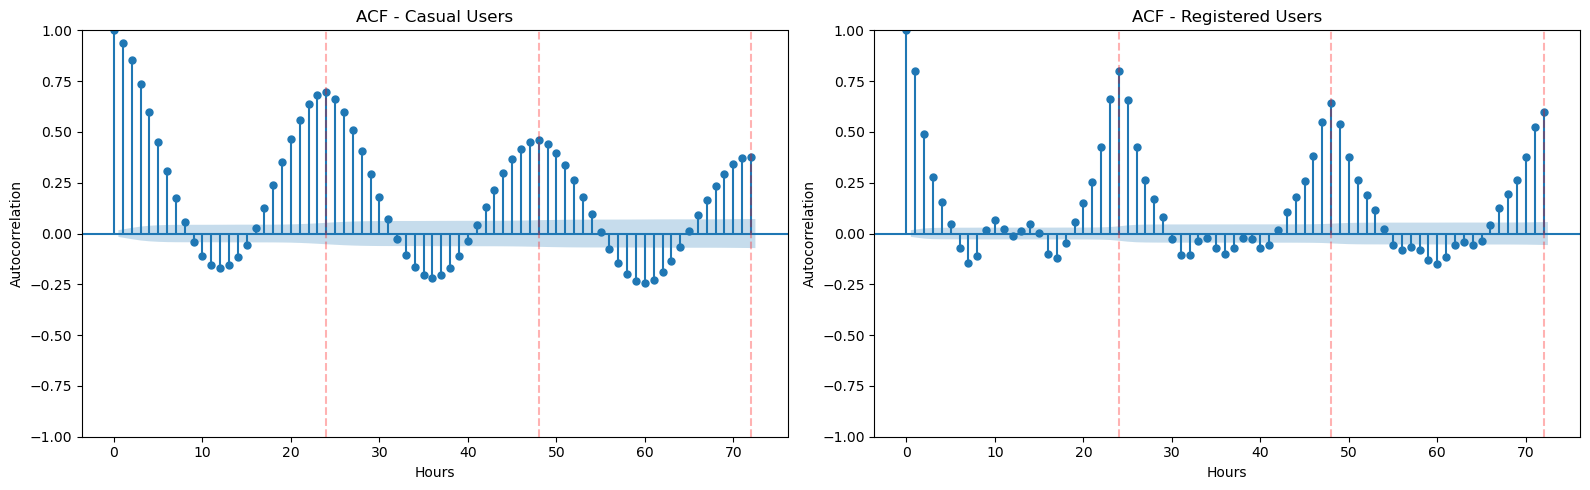

In [6]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima.arima.utils import nsdiffs

# 1 line, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Casual users (lags=72 to check 3 days)
plot_acf(y_casual_train, lags=72, ax=axes[0], title='ACF - Casual Users')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Autocorrelation')

# Add lines every 24 hours, which is our s
for i in range(24, 73, 24):
    axes[0].axvline(x=i, color='red', linestyle='--', alpha=0.3)

# Same for registered users
plot_acf(y_registered_train, lags=72, ax=axes[1], title='ACF - Registered Users')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Autocorrelation')
for i in range(24, 73, 24):
    axes[1].axvline(x=i, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

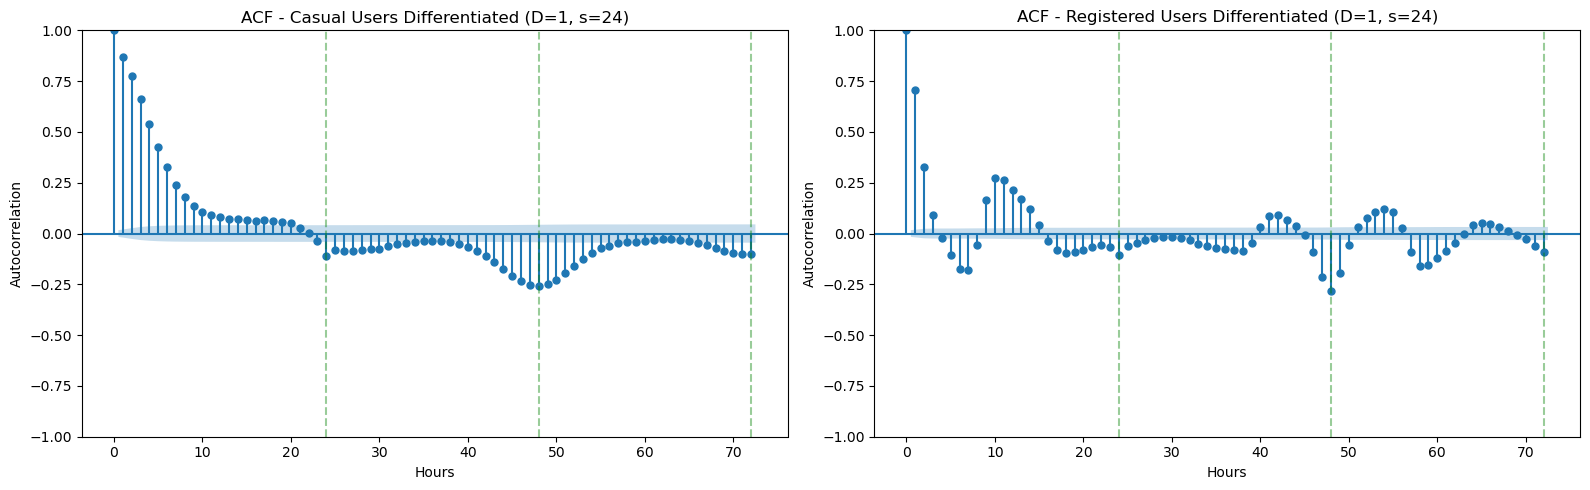

In [7]:
# Subtract from each value, the value from 24 hours ago
y_casual_diff = y_casual_train.diff(periods=24).dropna()
y_registered_diff = y_registered_train.diff(periods=24).dropna()


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(y_casual_diff, lags=72, ax=axes[0], title='ACF - Casual Users Differentiated (D=1, s=24)')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Autocorrelation')
for i in range(24, 73, 24):
    axes[0].axvline(x=i, color='green', linestyle='--', alpha=0.4) # Changed to green to differentiate it

plot_acf(y_registered_diff, lags=72, ax=axes[1], title='ACF - Registered Users Differentiated (D=1, s=24)')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Autocorrelation')
for i in range(24, 73, 24):
    axes[1].axvline(x=i, color='green', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

This means that we already have the D parameter for both time series, D = 1

### Applying AIC (Grid Search) --> p,q,P,Q

In [8]:
import pandas as pd
from typing import Union
from itertools import product
from tqdm.notebook import tqdm
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
from joblib import Parallel, delayed # NEW: Multiprocessing library

# Ignore convergence warnings
warnings.filterwarnings("ignore")

# NEW: Helper function. Joblib needs us to isolate the work of a single model.
def _fit_single_model(order, endog, d, D, s):
    try:
        model = SARIMAX(
            endog,
            order=(order[0], d, order[1]),
            seasonal_order=(order[2], D, order[3], s),
            simple_differencing=False,
            # Small extra trick so it doesn't get stuck looking for mathematical perfection:
            enforce_stationarity=False, 
            enforce_invertibility=False
        ).fit(disp=False)
        return [order, model.aic]
    except Exception:
        # If it fails, returns None so we ignore it later
        return None

def optimize_SARIMA_fast(endog: pd.Series, order_list: list, d: int, D: int, s: int, n_jobs: int = -1) -> pd.DataFrame:
    """
    Optimizes SARIMA using multiprocessing.
    n_jobs = -1 means "Use absolutely all available CPU cores".
    """
    print(f"Launching {len(order_list)} models in parallel...")
    
    # NEW: Parallelization magic. This launches the models simultaneously.
    # We use tqdm to keep the progress bar alive
    results = list(tqdm(
    Parallel(n_jobs=n_jobs, return_as="generator")(
        delayed(_fit_single_model)(order, endog, d, D, s) 
        for order in order_list
    ),
    total=len(order_list),
    desc="Evaluating combinations"
))

    # Clean up models that failed (those that returned None)
    valid_results = [r for r in results if r is not None]

    result_df = pd.DataFrame(valid_results, columns=['(p,q,P,Q)', 'AIC'])
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

#### *Casual*

In [10]:
# We maintain the ranges [0, 1, 2] which give 81 combinations
ps = range(0, 3, 1) 
qs = range(0, 3, 1) 
Ps = range(0, 3, 1) 
Qs = range(0, 3, 1) 
SARIMA_order_list = list(product(ps, qs, Ps, Qs))

d_val = 0
D_val = 1
s_val = 24

# THE DATA TRICK: We take only the last 1500 rows of training
# This represents approximately the last 60 days of history.
y_casual_subset = y_casual_train.iloc[-1500:]

print("Starting ULTRA FAST Grid Search for CASUAL users...")
# Call the new parallelized function
result_casual_fast = optimize_SARIMA_fast(y_casual_subset, SARIMA_order_list, d_val, D_val, s_val, n_jobs=8)

display(result_casual_fast.head())

Starting ULTRA FAST Grid Search for CASUAL users...
Launching 81 models in parallel...


Evaluating combinations:   0%|          | 0/81 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(2, 2, 1, 2)",12204.827130
1,"(2, 2, 2, 2)",12206.781352
2,"(2, 2, 0, 2)",12207.897005
3,"(1, 2, 1, 2)",12211.620189
4,"(1, 2, 2, 2)",12213.550432


#### *Registered*

In [11]:
# Now for the registered users

# THE DATA TRICK: We take only the last 1500 rows of training
# This represents approximately the last 60 days of history.
y_registered_subset = y_registered_train.iloc[-1500:]

print("Starting ULTRA FAST Grid Search for REGISTERED users...")
# Call the new parallelized function
result_registered_fast = optimize_SARIMA_fast(y_registered_subset, SARIMA_order_list, d_val, D_val, s_val)

display(result_registered_fast.head())

Starting ULTRA FAST Grid Search for REGISTERED users...
Launching 81 models in parallel...


Evaluating combinations:   0%|          | 0/81 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(2, 2, 2, 2)",15612.939322
1,"(1, 2, 2, 2)",15625.317343
2,"(2, 0, 2, 2)",15626.973385
3,"(2, 1, 2, 2)",15628.775844
4,"(0, 2, 2, 2)",15648.416415


### Residual analysis

#### *Casual*

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Retrieve the best parameters from the Grid Search for casual users
# Replace these variables with the actual numbers that won in the table!
best_p_casual, best_q_casual = 1, 1 
best_P_casual, best_Q_casual = 1, 1 

print(f"Training final CASUAL model with: (p={best_p_casual}, d=0, q={best_q_casual}) x (P={best_P_casual}, D=1, Q={best_Q_casual}, s=24)")

# 2. Train the final model
model_casual_final = SARIMAX(
    y_casual_train, 
    order=(best_p_casual, 0, best_q_casual), 
    seasonal_order=(best_P_casual, 1, best_Q_casual, 24), 
    simple_differencing=False,
    enforce_stationarity=False, 
    enforce_invertibility=False
)
fit_casual_final = model_casual_final.fit(disp=False)

# 3. Qualitative Diagnosis (The 4 plots)
fig = fit_casual_final.plot_diagnostics(figsize=(14, 10))
fig.suptitle('Residual Diagnosis - CASUAL Model', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Quantitative Diagnosis (Ljung-Box Test)
# We look up to lag 24 because that is our daily cycle
residuals_casual = fit_casual_final.resid

# dropna() is important because when applying D=1 we lose the first 24 residuals
lb_test_casual = acorr_ljungbox(residuals_casual.dropna(), lags=[12, 24])
print("\n--- Ljung-Box Test (Casual) ---")
print("H0: Residuals are white noise (independent).")
print("If p-value > 0.05, the model is GOOD (no patterns remain).")
display(lb_test_casual)

#### *Registered*

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Retrieve the best parameters from the Grid Search for casual users
# Replace these variables with the actual numbers that won in the table!
best_p_registered, best_q_registered = 1, 1 
best_P_registered, best_Q_registered = 1, 1 

print(f"Training final REGISTERED model with: (p={best_p_registered}, d=0, q={best_q_registered}) x (P={best_P_registered}, D=1, Q={best_Q_registered}, s=24)")

# 2. Train the final model
model_registered_final = SARIMAX(
    y_registered_train, 
    order=(best_p_registered, 0, best_q_registered), 
    seasonal_order=(best_P_registered, 1, best_Q_registered, 24), 
    simple_differencing=False,
    enforce_stationarity=False, 
    enforce_invertibility=False
)
fit_registered_final = model_registered_final.fit(disp=False)

# 3. Qualitative Diagnosis (The 4 plots)
fig = fit_registered_final.plot_diagnostics(figsize=(14, 10))
fig.suptitle('Residual Diagnosis - REGISTERED Model', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Quantitative Diagnosis (Ljung-Box Test)
# We look up to lag 24 because that is our daily cycle
residuals_registered = fit_registered_final.resid

# dropna() is important because when applying D=1 we lose the first 24 residuals
lb_test_registered = acorr_ljungbox(residuals_registered.dropna(), lags=[12, 24])
print("\n--- Ljung-Box Test (Registered) ---")
print("H0: Residuals are white noise (independent).")
print("If p-value > 0.05, the model is GOOD (no patterns remain).")
display(lb_test_registered)

### Results

#### *Casual*

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

# =====================================================================
# 1. GET PREDICTIONS
# =====================================================================
# Calculate at what numerical index our Test starts and ends
start_idx = len(y_casual_train)
end_idx = len(y_casual_train) + len(y_casual_test) - 1

# Ask the already trained model (fit_casual_final) to predict that range
casual_pred = fit_casual_final.get_prediction(start=start_idx, end=end_idx).predicted_mean

# =====================================================================
# 2. ERROR METRICS (Quantitative)
# =====================================================================
# Since we are not comparing with other models, a bar chart does not make sense. 
# We print it to screen to have mathematical validation.
mape_casual = mean_absolute_percentage_error(y_casual_test, casual_pred)
print(f"--- SARIMA Model Evaluation (Casual) ---")
print(f"MAPE (Mean Absolute Percentage Error): {mape_casual * 100:.2f}%")

# =====================================================================
# 3. VISUALIZATION (Qualitative)
# =====================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Draw a bit of the past (Train) to give context.
# Select only the last week of Train (7 days * 24 hours = 168 points)
ax.plot(y_casual_train.index[-168:], y_casual_train.iloc[-168:], label='Train (Last week)', color='gray')

# Draw the real Test data
ax.plot(y_casual_test.index, y_casual_test, label='Test (Reality)', color='blue')

# Draw our predictions
ax.plot(y_casual_test.index, casual_pred, label='SARIMA Prediction', color='green', linestyle='--')

# Gray shading to visually mark where the future (Test) begins
ax.axvspan(y_casual_test.index[0], y_casual_test.index[-1], color='#808080', alpha=0.1)

ax.set_title('SARIMA Prediction vs Reality - Casual Users', fontsize=16)
ax.set_xlabel('Time Index (Hours)')
ax.set_ylabel('Number of Casual Rentals')
ax.legend(loc='upper left')

# CRITICAL ZOOM: Show only 1 week before the cut and 1 week after.
# If you remove this, you will see thousands of hours squashed.
ax.set_xlim(y_casual_train.index[-168], y_casual_test.index[168]) 

plt.tight_layout()
plt.show()

##### Walk Forward

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
from tqdm.notebook import tqdm

# =====================================================================
# 1. GET PREDICTIONS (WALK-FORWARD VALIDATION - 24H)
# =====================================================================
print("Iniciando simulación Walk-Forward (Predicción de 24 en 24 horas)...")

predictions = []
# Clonamos el estado del modelo entrenado para ir actualizándolo
current_res = fit_casual_final 
step_size = 24
test_length = len(y_casual_test)

for i in tqdm(range(0, test_length, step_size), desc="Días simulados"):
    # 1. Predecir las siguientes 24 horas
    # Si estamos al final y quedan menos de 24h, predecimos solo lo que queda
    current_step = min(step_size, test_length - i)
    pred = current_res.forecast(steps=current_step)
    
    # Guardamos estas 24 horas de predicción en nuestra lista general
    predictions.extend(pred)
    
    # 2. Descubrimos la realidad: extraemos las 24 horas verdaderas del Test Set
    actual_data_chunk = y_casual_test.iloc[i : i + current_step]
    
    # 3. ACTUALIZACIÓN (La magia de Walk-Forward)
    # Le inyectamos los datos reales al modelo para que los asimile como "pasado"
    # refit=False asegura que no re-entrene los parámetros, solo actualiza la memoria
    current_res = current_res.append(actual_data_chunk, refit=False)

# Convertimos la lista de predicciones en una Serie de Pandas con el índice correcto
casual_pred_series = pd.Series(predictions, index=y_casual_test.index)

# =====================================================================
# 2. ERROR METRICS (Quantitative)
# =====================================================================
mape_casual = mean_absolute_percentage_error(y_casual_test, casual_pred_series)
print(f"\n--- SARIMA Walk-Forward Evaluation (Casual) ---")
print(f"MAPE (Mean Absolute Percentage Error a 24h vista): {mape_casual * 100:.2f}%")

# =====================================================================
# 3. VISUALIZATION (Qualitative)
# =====================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Contexto: Última semana del Train
ax.plot(y_casual_train.index[-168:], y_casual_train.iloc[-168:], label='Train (Last week)', color='gray')

# Realidad: El Test Set
ax.plot(y_casual_test.index, y_casual_test, label='Test (Reality)', color='blue')

# Predicción: Nuestra serie construida bloque a bloque de 24h
ax.plot(y_casual_test.index, casual_pred_series, label='SARIMA Walk-Forward (24h)', color='green', linestyle='--')

# Sombreado del Test Set
ax.axvspan(y_casual_test.index[0], y_casual_test.index[-1], color='#808080', alpha=0.1)

ax.set_title('Walk-Forward Prediction (24h) vs Reality - Casual Users', fontsize=16)
ax.set_xlabel('Time Index')
ax.set_ylabel('Number of Casual Rentals')
ax.legend(loc='upper left')

# CRITICAL ZOOM: Mantenemos el límite para ver el detalle de los cortes diarios
ax.set_xlim(y_casual_train.index[-168], y_casual_test.index[168]) 

plt.tight_layout()
plt.show()

#### *Registered*

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

# =====================================================================
# 1. GET PREDICTIONS
# =====================================================================
# Calculate at what numerical index our Test starts and ends
start_idx = len(y_registered_train)
end_idx = len(y_registered_train) + len(y_registered_test) - 1

# Ask the already trained model (fit_registered_final) to predict that range
registered_pred = fit_registered_final.get_prediction(start=start_idx, end=end_idx).predicted_mean

# =====================================================================
# 2. ERROR METRICS (Quantitative)
# =====================================================================
# Since we are not comparing with other models, a bar chart does not make sense. 
# We print it to screen to have mathematical validation.
mape_registered = mean_absolute_percentage_error(y_registered_test, registered_pred)
print(f"--- SARIMA Model Evaluation (Registered) ---")
print(f"MAPE (Mean Absolute Percentage Error): {mape_registered * 100:.2f}%")

# =====================================================================
# 3. VISUALIZATION (Qualitative)
# =====================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Draw a bit of the past (Train) to give context.
# Select only the last week of Train (7 days * 24 hours = 168 points)
ax.plot(y_registered_train.index[-168:], y_registered_train.iloc[-168:], label='Train (Last week)', color='gray')

# Draw the real Test data
ax.plot(y_registered_test.index, y_registered_test, label='Test (Reality)', color='blue')

# Draw our predictions
ax.plot(y_registered_test.index, registered_pred, label='SARIMA Prediction', color='green', linestyle='--')

# Gray shading to visually mark where the future (Test) begins
ax.axvspan(y_registered_test.index[0], y_registered_test.index[-1], color='#808080', alpha=0.1)

ax.set_title('SARIMA Prediction vs Reality - Registered Users', fontsize=16)
ax.set_xlabel('Time Index (Hours)')
ax.set_ylabel('Number of Registered Rentals')
ax.legend(loc='upper left')

# CRITICAL ZOOM: Show only 1 week before the cut and 1 week after.
# If you remove this, you will see thousands of hours squashed.
ax.set_xlim(y_registered_train.index[-168], y_registered_test.index[168]) 

plt.tight_layout()
plt.show()

## **SARIMAX**

We are looking for: (p, d, q) * (P, D, Q, s) + we add exogeneous variables 

We alredy have the restuls of the SARIMA model, so we will use them. Even though SARIMAX adds exogeneous variables, the basis of the model is the same. We could consider doing an extensive search again (as grid search), but taking into account the time we needed to execute the previous one, and that now we are adding a huge matrix with all the exogeneous variables (which would make things a lot slower), we will use the already calculated values.

* Casual Users:
    * p, d, q = 
    * P, D, Q = 
    * s = 

* Registered Users:
    * p, d, q = 
    * P, D, Q = 
    * s = 

### Training

In [ ]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Reutilizamos los hiperparámetros ganadores de tu Grid Search rápido
best_p_casual, best_q_casual = 1, 1 # Sustituir por tus reales
best_P_casual, best_Q_casual = 1, 1 # Sustituir por tus reales

print("Entrenando modelo SARIMAX DEFINITIVO (Casuales) con variables exógenas...")

# La gran diferencia: Añadimos exog=X_train
model_sarimax_casual = SARIMAX(
    endog=y_casual_train, 
    exog=X_train,  # <--- MATRIZ EXÓGENA AQUÍ
    order=(best_p_casual, 0, best_q_casual), 
    seasonal_order=(best_P_casual, 1, best_Q_casual, 24), 
    simple_differencing=False,
    enforce_stationarity=False, 
    enforce_invertibility=False
)

# Entrenamos
fit_sarimax_casual = model_sarimax_casual.fit(disp=False)
print("Entrenamiento completado.")

### Residual analysis

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# Gráficos cualitativos
fig = fit_sarimax_casual.plot_diagnostics(figsize=(14, 10))
fig.suptitle('Diagnóstico de Residuos - Modelo SARIMAX (Casuales)', fontsize=16)
plt.tight_layout()
plt.show()

# Test Cuantitativo (Ljung-Box)
residuals_sarimax = fit_sarimax_casual.resid
lb_test_sarimax = acorr_ljungbox(residuals_sarimax.dropna(), lags=[12, 24])

print("\n--- Test Ljung-Box (SARIMAX Casuales) ---")
display(lb_test_sarimax)

### Results

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from tqdm.notebook import tqdm

print("Iniciando simulación Walk-Forward (SARIMAX - 24h)...")

predictions_sarimax = []
current_res_sarimax = fit_sarimax_casual 
step_size = 24
test_length = len(y_casual_test)

for i in tqdm(range(0, test_length, step_size), desc="Días simulados"):
    current_step = min(step_size, test_length - i)
    
    # 1. Extraemos el CLIMA FUTURO (X_test) para estas 24 horas
    exog_future_chunk = X_test.iloc[i : i + current_step]
    
    # 2. Predecir, dándole al modelo ese clima futuro
    pred = current_res_sarimax.forecast(steps=current_step, exog=exog_future_chunk)
    predictions_sarimax.extend(pred)
    
    # 3. Descubrimos la REALIDAD de los alquileres (y_test)
    actual_y_chunk = y_casual_test.iloc[i : i + current_step]
    
    # 4. ACTUALIZACIÓN DE MEMORIA
    # OJO AQUÍ: Tenemos que inyectarle TANTO la realidad objetivo (endog) como la exógena (exog)
    current_res_sarimax = current_res_sarimax.append(
        endog=actual_y_chunk, 
        exog=exog_future_chunk, 
        refit=False
    )

# Formatear resultados
casual_pred_sarimax_series = pd.Series(predictions_sarimax, index=y_casual_test.index)

# Calcular error final
mape_sarimax = mean_absolute_percentage_error(y_casual_test, casual_pred_sarimax_series)
print(f"\n--- Evaluación Final SARIMAX Walk-Forward (Casual) ---")
print(f"MAPE (Error a 24h vista con clima): {mape_sarimax * 100:.2f}%")

# Dibujar el mismo gráfico de ZOOM que diseñamos antes
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_casual_train.index[-168:], y_casual_train.iloc[-168:], label='Train (Última semana)', color='gray')
ax.plot(y_casual_test.index, y_casual_test, label='Test (Realidad)', color='blue')
ax.plot(y_casual_test.index, casual_pred_sarimax_series, label='Predicción SARIMAX (24h)', color='green', linestyle='--')
ax.axvspan(y_casual_test.index[0], y_casual_test.index[-1], color='#808080', alpha=0.1)
ax.set_title('Predicción SARIMAX vs Realidad (Con variables exógenas)', fontsize=16)
ax.set_xlabel('Índice Temporal')
ax.set_ylabel('Alquileres Casuales')
ax.legend(loc='upper left')
ax.set_xlim(y_casual_train.index[-168], y_casual_test.index[168]) 
plt.tight_layout()
plt.show()